In [73]:
# Loading the dataset using pandas

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('customer_shopping_behavior.csv')

In [55]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [57]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [58]:
# Checking if missing data or null values are present in the dataset

df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [59]:
# Imputing missing values in Review Rating column with the median rating of the product category

df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [60]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [61]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [62]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

In [63]:
# create a new column age_group
labels = ['Young Adult', 'Adult', 'Middle-aged', 'Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels = labels)

In [64]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle-aged
1,19,Young Adult
2,50,Middle-aged
3,21,Young Adult
4,45,Middle-aged
5,46,Middle-aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle-aged


In [65]:
# create new column purchase_frequency_days

frequency_mapping = {
    'Fortnightly': 14,
    'Weekly': 7,
    'Monthly': 30,
    'Quarterly': 90,
    'Bi-Weekly': 14,
    'Annually': 365,
    'Every 3 Months': 90
}

df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)

In [66]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14,Fortnightly
1,14,Fortnightly
2,7,Weekly
3,7,Weekly
4,365,Annually
5,7,Weekly
6,90,Quarterly
7,7,Weekly
8,365,Annually
9,90,Quarterly


In [67]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


In [68]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [69]:
# Dropping promo code used column

df = df.drop('promo_code_used', axis=1)

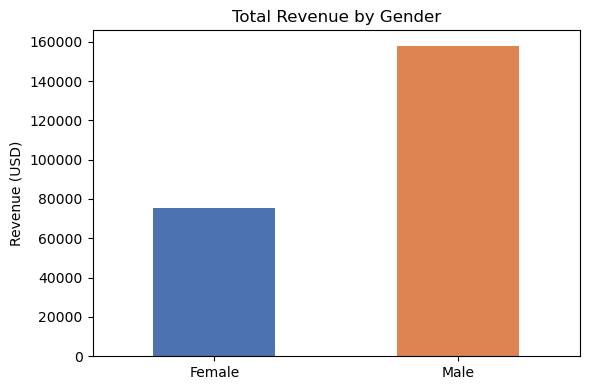

In [75]:
fig, ax = plt.subplots(figsize=(6,4))
df.groupby('Gender')['Purchase Amount (USD)'].sum().plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_title('Total Revenue by Gender')
ax.set_ylabel('Revenue (USD)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

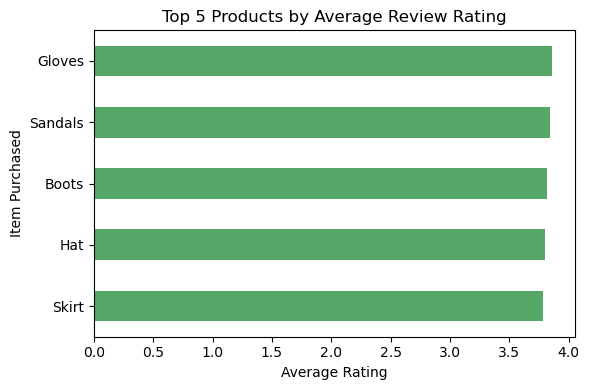

In [81]:
top5 = df.groupby('Item Purchased')['Review Rating'].mean().sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(6,4))
top5.plot(kind='barh', color='#55A868', ax=ax)
ax.set_title('Top 5 Products by Average Review Rating')
ax.set_xlabel('Average Rating')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

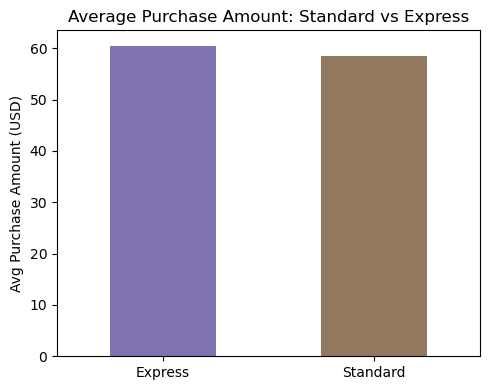

In [82]:
shipping = df[df['Shipping Type'].isin(['Standard','Express'])]

fig, ax = plt.subplots(figsize=(5,4))
shipping.groupby('Shipping Type')['Purchase Amount (USD)'].mean().plot(kind='bar', color=['#8172B2','#937860'], ax=ax)
ax.set_title('Average Purchase Amount: Standard vs Express')
ax.set_ylabel('Avg Purchase Amount (USD)')
ax.set_xlabel('')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

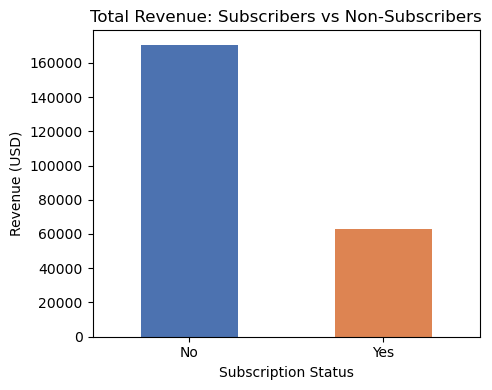

In [83]:
fig, ax = plt.subplots(figsize=(5,4))
df.groupby('Subscription Status')['Purchase Amount (USD)'].sum().plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_title('Total Revenue: Subscribers vs Non-Subscribers')
ax.set_ylabel('Revenue (USD)')
ax.set_xlabel('Subscription Status')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

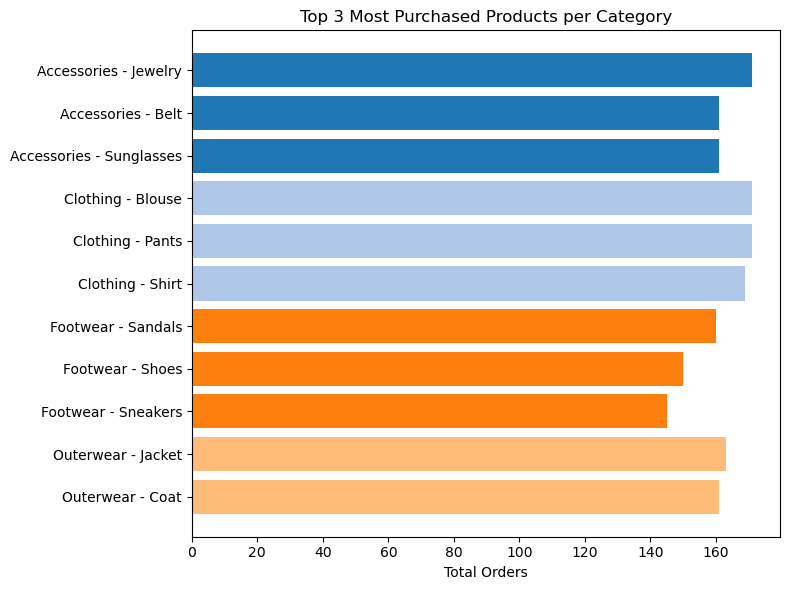

In [85]:
top3_per_cat = (
    df.groupby(['Category','Item Purchased']).size()
    .reset_index(name='Total Orders')
    .sort_values(['Category','Total Orders'], ascending=[True, False])
    .groupby('Category').head(3)
)

fig, ax = plt.subplots(figsize=(8,6))
colors = plt.cm.tab20.colors
for i, cat in enumerate(top3_per_cat['Category'].unique()):
    subset = top3_per_cat[top3_per_cat['Category'] == cat]
    ax.barh(subset['Category'] + ' - ' + subset['Item Purchased'], subset['Total Orders'], color=colors[i])

ax.set_title('Top 3 Most Purchased Products per Category')
ax.set_xlabel('Total Orders')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [70]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

## Connecting Python script to PostgreSQL

In [18]:
!pip install psycopg2-binary sqlalchemy

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   --- ------------------------------------ 0.3/2.8 MB ? eta -:--:--
   ------- -------------------------------- 0.5/2.8 MB 250.1 kB/s eta 0:00:09
   ------- -------------------------------- 0.5/2.8 MB 250.1 kB/s eta 0:00:09
   ------- -----

## Code for MySQL

In [20]:
!pip install pymysql sqlalchemy

## Code for MS SQL Server

In [31]:
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

username = "root"
password = quote_plus("Pratik")
host = "localhost"
port = 3306
database = "customer_behavior"

engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

try:
    with engine.connect() as conn:
        print("Database Connected Successfully!")
        print(conn.execute(text("SELECT VERSION()")).fetchone())
except Exception as e:
    print("Connection Failed")
    print(e)

✅ Database Connected Successfully!
('8.0.43',)


In [32]:
table_name = "customer"

df.to_sql(
    table_name,
    con=engine,
    if_exists="replace",
    index=False
)

print("Data uploaded successfully!")

✅ Data uploaded successfully!


In [33]:
import pandas as pd

df2 = pd.read_sql("SELECT * FROM customer LIMIT 5", engine)

print(df2)

   customer_id  age gender item_purchased  category  purchase_amount  \
0            1   55   Male         Blouse  Clothing               53   
1            2   19   Male        Sweater  Clothing               64   
2            3   50   Male          Jeans  Clothing               73   
3            4   21   Male        Sandals  Footwear               90   
4            5   45   Male         Blouse  Clothing               49   

        location size      color  season  review_rating subscription_status  \
0       Kentucky    L       Gray  Winter            3.1                 Yes   
1          Maine    L     Maroon  Winter            3.1                 Yes   
2  Massachusetts    S     Maroon  Spring            3.1                 Yes   
3   Rhode Island    M     Maroon  Spring            3.5                 Yes   
4         Oregon    M  Turquoise  Spring            2.7                 Yes   

   shipping_type discount_applied  previous_purchases payment_method  \
0        Express    

In [34]:
!pip install pyodbc sqlalchemy 